In [9]:
%load_ext autoreload

import sys
import os
import pandas as pd
import numpy as np
import torch
import copy
import pandas as pd
import torch
import yaml

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# def set_seed(seed):
#     # random.seed(seed)
#     # np.random.seed(seed)
#     torch.manual_seed(seed)
#     # torch.cuda.manual_seed(seed)
#     # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
#     # torch.backends.cudnn.deterministic = True
#     # torch.backends.cudnn.benchmark = False
#     print(f"Random seed set to: {seed}")

# SEED = 50
# set_seed(SEED)

In [11]:
bench_mark_return = pd.read_csv("0.003_benchmark.csv", header=0, index_col=0)

In [12]:
def calculate_annual_return(returns, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    cumulative = np.prod(1 + returns)
    n_periods = len(returns)
    return cumulative ** (annual_factor / n_periods) - 1


def calculate_max_drawdown(returns):
    returns = np.array(returns, dtype=np.float64)
    cumulative_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_returns - running_max) / running_max
    return abs(np.min(drawdowns))

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


def calculate_downside_deviation(returns, threshold=0.0, annual_factor=252, annualize=True):
    downside = np.minimum(returns - threshold, 0)
    dd = np.sqrt(np.mean(downside ** 2))
    return dd * np.sqrt(annual_factor) if annualize else dd


def calculate_annualized_sortino_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return = annual_return - risk_free_rate
    downside_dev = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    return excess_return / downside_dev if downside_dev != 0 else 0.0


def calculate_calmar_ratio(returns, annual_factor=252):
    """
    Calmar Ratio = Annualized Return / Maximum Drawdown
    """
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    max_drawdown = calculate_max_drawdown(returns)
    
    return  (annual_return) / max_drawdown if max_drawdown != 0 else 0.0  # MDD가 0이면 0 반환


# def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=12):
#     returns = np.array(returns, dtype=np.float64)
#     geo_return = np.prod(1 + returns) ** (1 / len(returns)) - 1
#     risk_free_rate /= annual_factor
#     excess_geo_return = geo_return - risk_free_rate
#     std_dev = np.std(returns, ddof=1)
#     return (excess_geo_return * annual_factor) / (std_dev * np.sqrt(annual_factor)) if std_dev != 0 else 0.0

def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return =  (annual_return - risk_free_rate) 
    if excess_return == 0:
        sign = 1
    else:
        sign = excess_return / abs(excess_return)
    annual_std_dev = calculate_volatility(returns, annual_factor)
    # 연환산 수익률과 표준편차
    modified_sharpe =  excess_return / (annual_std_dev ** sign)  if annual_std_dev != 0 else 0.0
    return modified_sharpe


def calculate_cumulative_return(returns):
    returns = np.array(returns, dtype=np.float64)
    return np.prod(1 + returns) - 1

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# 성과 지표 계산 함수 (파라미터화)
def calculate_performance_metrics(returns, annual_factor=252, risk_free_rate=0.0):
    cumulative_returns = (1 + returns).cumprod()
    # cagr = calculate_cagr(returns, annual_factor)
    annual_return = calculate_annual_return(returns, annual_factor)
    sharpe_ratio = calculate_sharpe_ratio(returns, risk_free_rate, annual_factor)
    mdd = calculate_max_drawdown(returns)
    volatility = calculate_volatility(returns, annual_factor)
    sortino_ratio = calculate_annualized_sortino_ratio(returns, risk_free_rate, annual_factor)
    downside_deviation = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    # Calmar Ratio 계산
    calmar_ratio = calculate_calmar_ratio(returns, annual_factor)
    

    return {
        'Cumulative Return': cumulative_returns.iloc[-1] - 1,
        'Annual Return': annual_return,
        # 'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'MDD': mdd,
        'Downside Deviation': downside_deviation,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio
    }


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


import matplotlib.pyplot as plt
import numpy as np




In [13]:
metrics_summary = get_performance_summary(
    bench_mark_return,
    annual_factor=12,
    risk_free_rate=0.0
)

display(metrics_summary)


,Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD,Downside Deviation,Sortino Ratio,Calmar Ratio
risk_parity,0.483225,0.064223,0.144680,0.443898,0.237834,0.100482,0.639150,0.270033
min_var,0.789562,0.096244,0.105493,0.912327,0.171656,0.064117,1.501081,0.560681
max_sharpe,0.691300,0.086513,0.192780,0.448764,0.409078,0.114221,0.757414,0.211482
paa,0.168702,0.024920,0.212708,0.117157,0.470926,0.146801,0.169756,0.052918
equal_strategy,0.559529,0.072686,0.137197,0.529793,0.265680,0.094572,0.768581,0.273586
equal_asset_weight,0.507161,0.066917,0.153110,0.437048,0.307545,0.104923,0.637771,0.217583


In [14]:
metrics_summary.T

,risk_parity,min_var,max_sharpe,paa,equal_strategy,equal_asset_weight
Cumulative Return,0.483225,0.789562,0.691300,0.168702,0.559529,0.507161
Annual Return,0.064223,0.096244,0.086513,0.024920,0.072686,0.066917
Volatility,0.144680,0.105493,0.192780,0.212708,0.137197,0.153110
Sharpe Ratio,0.443898,0.912327,0.448764,0.117157,0.529793,0.437048
MDD,0.237834,0.171656,0.409078,0.470926,0.265680,0.307545
Downside Deviation,0.100482,0.064117,0.114221,0.146801,0.094572,0.104923
Sortino Ratio,0.639150,1.501081,0.757414,0.169756,0.768581,0.637771
Calmar Ratio,0.270033,0.560681,0.211482,0.052918,0.273586,0.217583


In [8]:
zero_row = pd.DataFrame([[0]*total_df.shape[1]], columns=total_df.columns)


NameError: name 'total_df' is not defined

In [31]:
zero_row.index = ["2019-01-01"]

In [35]:
total_df = pd.concat([zero_row, total_df])


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_cumulative_returns_from_df(returns_df: pd.DataFrame,
                                     title='Cumulative Returns',
                                     y_range=(0.0, 5),
                                     test_start_date=None):

    plt.figure(figsize=(25, 8))

    # 누적 로그 수익률 계산
    cum_returns = np.log1p(returns_df).cumsum()

    # 강조할 전략
    bold_strategies = ['grpo_best', 'grpo_worst']

    # 더 구분되는 색상 팔레트 사용
    color_map = {
        'risk_parity': '#1f77b4',          # Blue
        'min_var': '#ff7f0e',              # Orange
        'max_sharpe': '#2ca02c',           # Green
        'paa': '#d62728',                  # Red
        'equal_strategy': '#9467bd',       # Purple
        'equal_asset_weight': '#8c564b',   # Brown

        'ppo_best': '#17becf',             # Teal
        'ppo_worst': '#bcbd22',            # Olive
        'sac_best': '#e377c2',             # Pink
        'sac_worst': '#7f7f7f',            # Gray
        'grpo_best': '#000000',            # Black (굵은)
        'grpo_worst': '#ff0000',           # Bright Red (굵은)
    }

    for col in cum_returns.columns:
        linewidth = 3.5 if col in bold_strategies else 2.0
        color = color_map.get(col, None)

        plt.plot(
            cum_returns.index,
            cum_returns[col],
            label=col,
            linewidth=linewidth,
            color=color
        )

    # x축 날짜 형식

    plt.xticks(rotation=45, fontsize=14)

    if test_start_date:
        plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')

    plt.ylim(y_range)
    plt.yticks(fontsize=18)
    plt.ylabel('Log Cumulative Returns', fontsize=18)

    plt.xlabel('Date', fontsize=16)
    plt.title(title, fontsize=20)
    plt.legend(loc='upper left', fontsize=16, ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


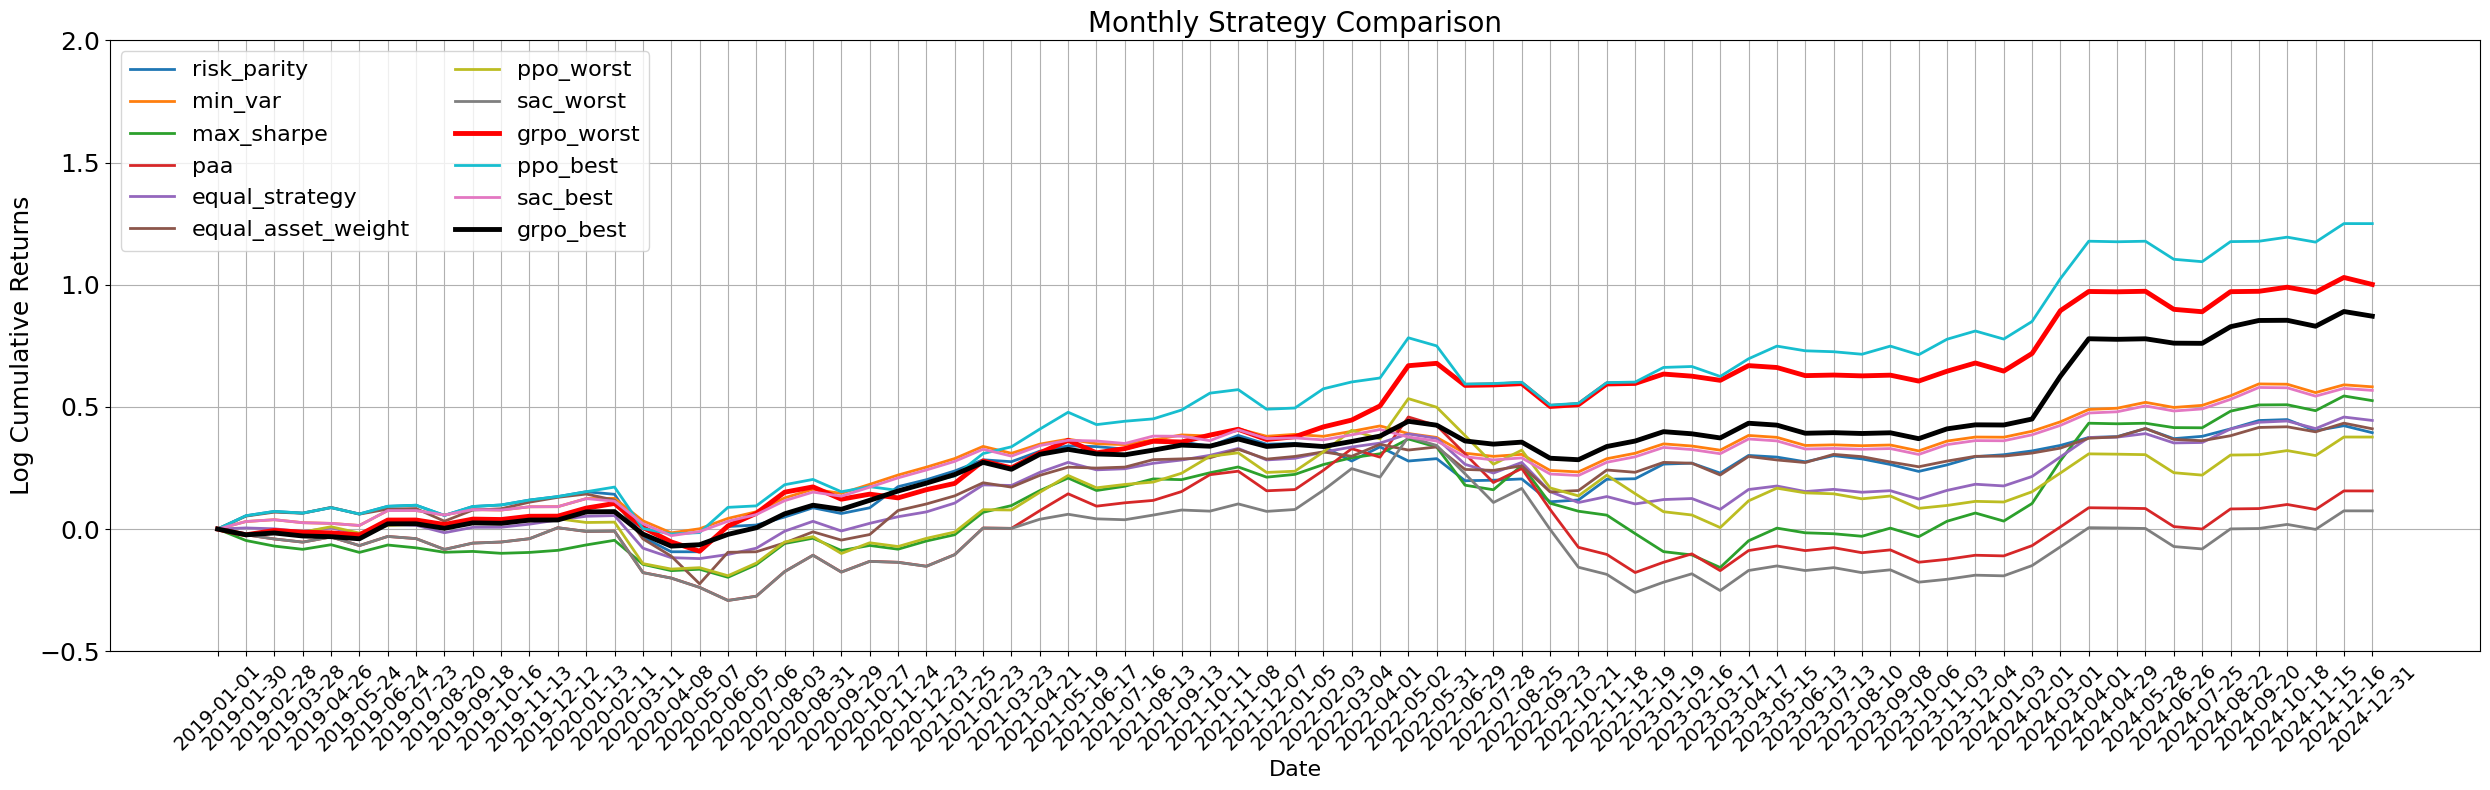

In [47]:
plot_cumulative_returns_from_df(total_df, title="Monthly Strategy Comparison", y_range=(-0.5, 2))


In [56]:
imp = total_df[["equal_strategy", "equal_asset_weight"]]

In [61]:
imp.to_csv("./portfolio_price_discrete_rebal_step_1m_concat_asset/result/equal_strategy.csv")